# Monte Carlo Blackjack Policy Evaluation
First-Visit MC with visualizations.

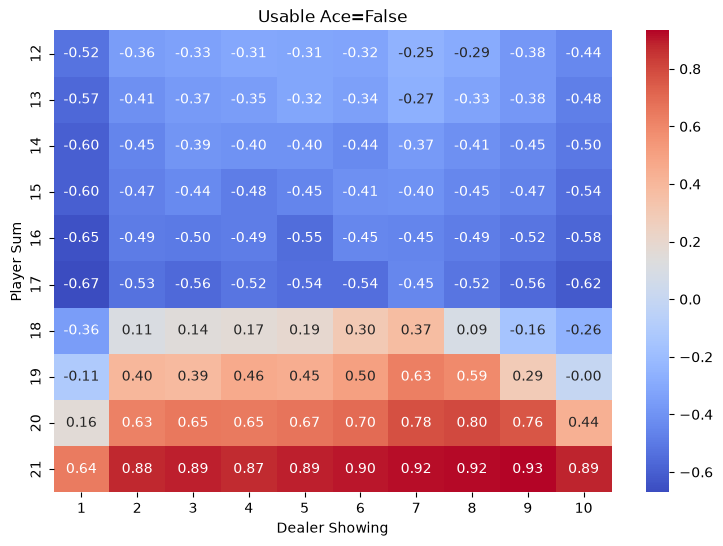

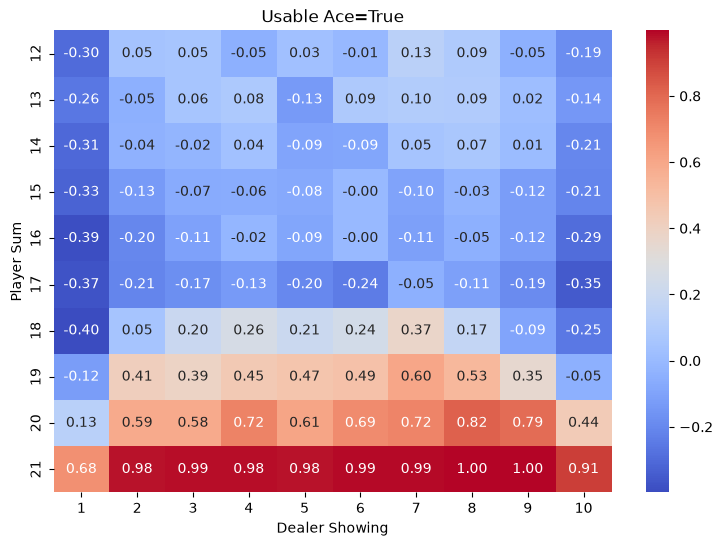

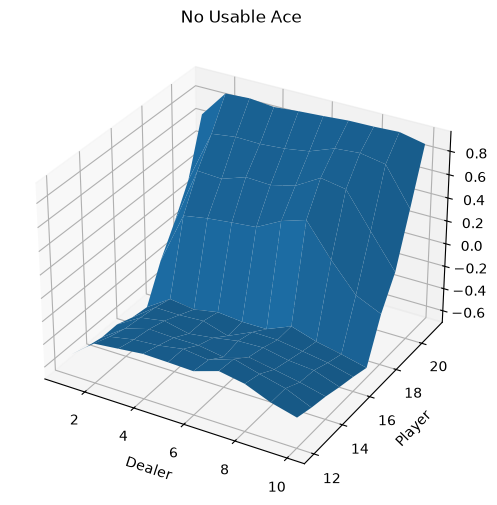

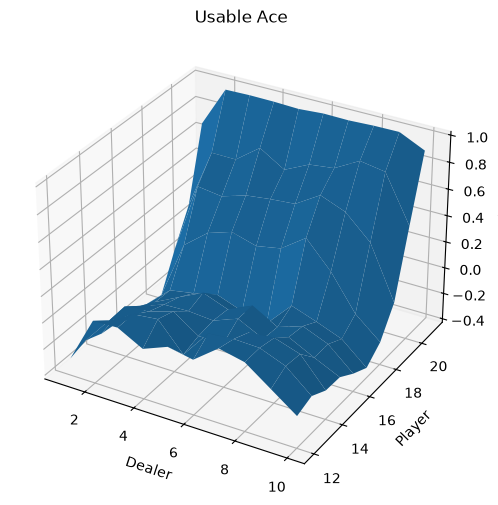

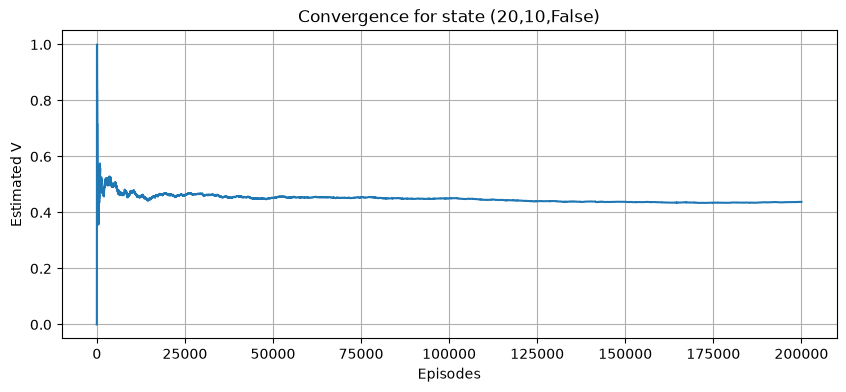

    Player Sum  Dealer     Value
0           18       1 -0.355964
1           18       2  0.106984
2           18       3  0.143794
3           18       4  0.167656
4           18       5  0.188143
5           18       6  0.301145
6           18       7  0.370690
7           18       8  0.088309
8           18       9 -0.156530
9           18      10 -0.256311
10          19       1 -0.112288
11          19       2  0.400521
12          19       3  0.387646
13          19       4  0.460439
14          19       5  0.450469
15          19       6  0.502318
16          19       7  0.627420
17          19       8  0.589446
18          19       9  0.289744
19          19      10 -0.001521


In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

env=gym.make("Blackjack-v1")

def policy(state):
    ps,dc,ua=state
    return 0 if ps>=18 else 1

def generate_episode(env):
    ep=[]
    s,_=env.reset()
    done=False
    while not done:
        a=policy(s)
        ns,r,term,trunc,_=env.step(a)
        ep.append((s,a,r))
        s=ns
        done=term or trunc
    return ep

def first_visit_mc(episodes=200000,target=(20,10,False)):
    rs=defaultdict(float); rc=defaultdict(int); V=defaultdict(float); hist=[]
    for i in range(episodes):
        ep=generate_episode(env)
        G=0; visited=set()
        for t in reversed(range(len(ep))):
            s,a,r=ep[t]
            G+=r
            if s not in visited:
                visited.add(s)
                rs[s]+=G; rc[s]+=1; V[s]=rs[s]/rc[s]
        hist.append(V[target])
    return V,hist

V,history=first_visit_mc()

def heatmap(usable):
    data=np.zeros((10,10))
    for p in range(12,22):
        for d in range(1,11):
            data[p-12,d-1]=V[(p,d,usable)]
    plt.figure(figsize=(9,6))
    sns.heatmap(data,annot=True,fmt=".2f",cmap="coolwarm",
                xticklabels=range(1,11),yticklabels=range(12,22))
    plt.xlabel("Dealer Showing"); plt.ylabel("Player Sum")
    plt.title(f"Usable Ace={usable}")
    plt.show()
    return data

noace=heatmap(False)
ace=heatmap(True)

from mpl_toolkits.mplot3d import Axes3D
def surface(data,title):
    x=np.arange(1,11); y=np.arange(12,22)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure(figsize=(8,6))
    ax=fig.add_subplot(111,projection='3d')
    ax.plot_surface(X,Y,data)
    ax.set_xlabel("Dealer"); ax.set_ylabel("Player"); ax.set_zlabel("V")
    ax.set_title(title)
    plt.show()
surface(noace,"No Usable Ace")
surface(ace,"Usable Ace")

plt.figure(figsize=(10,4))
plt.plot(history)
plt.xlabel("Episodes"); plt.ylabel("Estimated V")
plt.title("Convergence for state (20,10,False)")
plt.grid()
plt.show()

import pandas as pd
rows=[]
for p in range(18,22):
    for d in range(1,11):
        rows.append([p,d,V[(p,d,False)]])
df=pd.DataFrame(rows,columns=["Player Sum","Dealer","Value"])
print(df.head(20))
